# **5. ConvLSTM**

## **5.1. Librerias**

In [1]:
import os
import copy
import random
import optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

import geopandas as gpd
from libpysal.weights import Queen
import sys
import time



## **5.2. Configuración Reproducibilidad**

In [ ]:
SEEDS = [42, 123, 2024]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Python: 3.10.20 (main, Mar  3 2026, 09:24:47) [GCC 13.3.0]
Torch: 2.11.0+cu130
Numpy: 2.2.6
Pandas: 2.3.3


El entorno de ejecución utiliza PyTorch 2.11 con soporte CUDA 13.0 y una GPU NVIDIA GeForce RTX 5050 Laptop, lo que permite acelerar significativamente el entrenamiento de modelos de deep learning. Además, la configuración de semillas múltiples y versiones recientes de librerías como NumPy y Pandas favorece la reproducibilidad y estabilidad experimental.


In [ ]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True)
    os.environ["PYTHONHASHSEED"] = str(seed)

    print(f"Seed fijada: {seed}")


def seed_worker(worker_id):

    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


g = torch.Generator()

Este código implementa una estrategia exhaustiva de reproducibilidad en experimentos con PyTorch, fijando semillas en random, numpy y torch, además de desactivar optimizaciones no deterministas de CUDA (como cudnn.benchmark) para garantizar resultados consistentes entre ejecuciones. Asimismo, se controla la aleatoriedad en los *data loaders* mediante seed_worker y un generador de PyTorch, asegurando coherencia en el muestreo paralelo de datos.

## **5.3. Carga de Datos & Preprocesamiento**

### **5.3.1. Cargando Datos**

In [ ]:
df = pd.read_csv("/home/guirlessa/Dl_Proyecto_Dengue/Bases_Datos/df_full.csv")
df.head()

,departamento,fecha_inicio,ano,semana,casos,casos_mujeres,casos_hombres,casos_rural,casos_urbano,(0_5],...,precip_lag_12,precip_lag_20,temp_c,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_8,temp_lag_12,temp_lag_20
0,Amazonas,2012-01-02,2012,1,0.0,0,0,0,0,0,...,50.983546,39.108242,24.848668,24.890654,24.334752,24.545618,25.345678,25.278160,25.874930,24.364443
1,Amazonas,2012-01-09,2012,2,0.0,0,0,0,0,0,...,61.818291,62.830250,24.729721,24.848668,24.890654,24.334752,24.545618,25.084141,25.495665,24.971798
2,Amazonas,2012-01-16,2012,3,0.0,0,0,0,0,0,...,24.950393,42.988018,24.638674,24.729721,24.848668,24.890654,24.334752,25.751070,25.760539,25.304947
3,Amazonas,2012-01-23,2012,4,0.0,0,0,0,0,0,...,88.169343,56.572467,25.164008,24.638674,24.729721,24.848668,24.890654,25.284157,25.842089,25.166142
4,Amazonas,2012-01-30,2012,5,0.0,0,0,0,0,0,...,56.271440,74.893047,24.604644,25.164008,24.638674,24.729721,24.848668,25.345678,25.278160,25.312395


In [ ]:
print("El dataframe tiene {0} filas y {1} columnas.".format(df.shape[0], df.shape[1]))

El dataframe tiene 21664 filas y 54 columnas.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21664 entries, 0 to 21663
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   departamento        21664 non-null  object 
 1   fecha_inicio        21664 non-null  object 
 2   ano                 21664 non-null  int64  
 3   semana              21664 non-null  int64  
 4   casos               21664 non-null  float64
 5   casos_mujeres       21664 non-null  int64  
 6   casos_hombres       21664 non-null  int64  
 7   casos_rural         21664 non-null  int64  
 8   casos_urbano        21664 non-null  int64  
 9   (0_5]               21664 non-null  int64  
 10  (5_13]              21664 non-null  int64  
 11  (13_26]             21664 non-null  int64  
 12  (26_60]             21664 non-null  int64  
 13  60_mas              21664 non-null  int64  
 14  casos_Contributivo  21664 non-null  int64  
 15  casos_No_asegurado  21664 non-null  int64  
 16  caso

Se observa que la variable `fecha_inicio` está tipificada como `object`, cuando en realidad debería corresponder al tipo `datetime`. Por ello, se procederá a realizar la conversión adecuada para garantizar un manejo correcto de fechas en las etapas posteriores de modelado.

In [ ]:
df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"])

También se procede a organizar los registros del DataFrame según el departamento y la fecha de inicio, con el objetivo de asegurar una estructura temporal coherente que facilite el análisis y el posterior proceso de modelado.

In [ ]:
df = df.sort_values(
    ["departamento", "fecha_inicio"]
).reset_index(drop=True)


### **5.3.2. Feature Enginering**

Con el fin de incorporar la estacionalidad anual de la enfermedad, se construyeron las variables cíclicas week_sin y week_cos a partir de la semana epidemiológica normalizada. Esta transformación permite representar la naturaleza periódica del calendario, preservando la continuidad entre el final y el inicio de cada año, y facilitando que los modelos capturen patrones estacionales recurrentes asociados a la transmisión del dengue.

In [ ]:
weeks_per_year = df.groupby("ano")["semana"].transform("max")

df["week_norm"] = df["semana"] / weeks_per_year

df["week_sin"] = np.sin(2 * np.pi * df["week_norm"])

df["week_cos"] = np.cos(2 * np.pi * df["week_norm"])

Este conjunto de FEATURES define el espacio de variables utilizado para el modelado, combinando información temporal, climática y sociodemográfica. En particular, se incorporan múltiples rezagos (lags) de la incidencia y variables meteorológicas (temperatura, humedad y precipitación) para capturar dependencias temporales y efectos retardados, junto con variables estructurales como población y proporción rural. Adicionalmente, las componentes cíclicas `week_sin` y `week_cos` permiten modelar la estacionalidad semanal de forma continua, evitando discontinuidades propias de una codificación directa del tiempo.

In [ ]:
FEATURES = [

    "inc_lag_1",
    "inc_lag_2",
    "inc_lag_3",
    "inc_lag_4",
    "inc_lag_8",
    "inc_lag_12",
    "inc_lag_20",

    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_4",
    "temp_lag_8",
    "temp_lag_12",
    "temp_lag_20",

    "humedad_lag_1",
    "humedad_lag_2",
    "humedad_lag_4",
    "humedad_lag_8",
    "humedad_lag_12",
    "humedad_lag_20",

    "precip_lag_1",
    "precip_lag_2",
    "precip_lag_4",
    "precip_lag_8",
    "precip_lag_12",
    "precip_lag_20",

    "poblacion",
    "prop_rural",

    "week_sin",
    "week_cos"
]

Asimismo, durante el análisis exploratorio de datos se observó que la variable de incidencia presentaba una distribución fuertemente asimétrica hacia la derecha, caracterizada por la presencia de valores extremos asociados a periodos epidémicos. Debido a ello, se consideró necesario aplicar una transformación logarítmica con el objetivo de reducir la asimetría, estabilizar la varianza y facilitar que los modelos capturen de manera más adecuada la estructura temporal y los patrones subyacentes de la incidencia del dengue.

In [ ]:
df["incidencia_log"] = np.log1p(df["incidencia"])

TARGET = "incidencia_log"

Con el fin de evaluar el efecto de la transformación logarítmica, se compararon las distribuciones de la incidencia antes y después del preprocesamiento. La distribución original presentaba una marcada asimetría positiva y una alta concentración de valores extremos asociados a periodos epidémicos. Tras aplicar la transformación logarítmica (log1p), se observó una reducción significativa del sesgo y una distribución más equilibrada, lo que contribuye a estabilizar la varianza y facilita la identificación de patrones temporales por parte de los modelos predictivos.

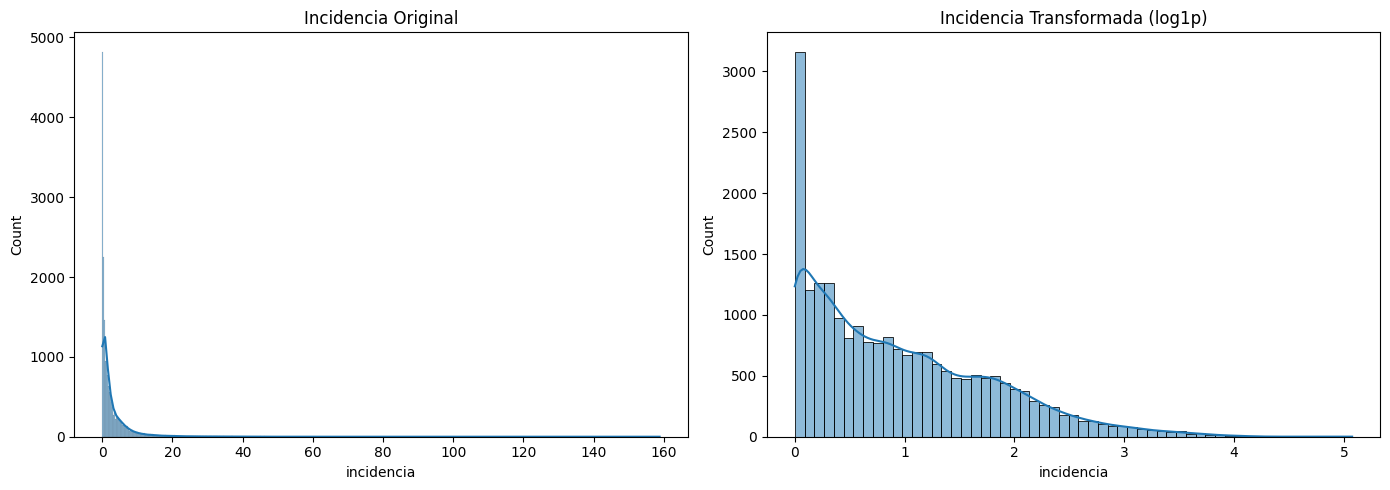

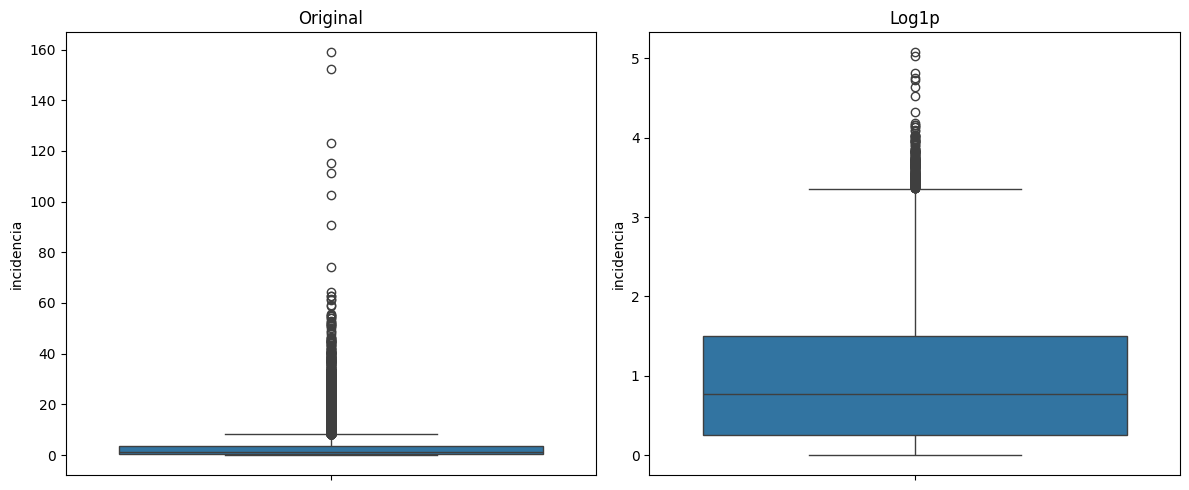

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["incidencia"],
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Incidencia Original")

sns.histplot(
    np.log1p(df["incidencia"]),
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Incidencia Transformada (log1p)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["incidencia"], ax=axes[0])
axes[0].set_title("Original")

sns.boxplot(y=np.log1p(df["incidencia"]), ax=axes[1])
axes[1].set_title("Log1p")

plt.tight_layout()
plt.show()

### **5.3.3. Grafo Espacial**

In [ ]:
departments = sorted(df["departamento"].unique())

dept_to_idx = {d: i for i, d in enumerate(departments)}

idx_to_dept = {i: d for d, i in dept_to_idx.items()}

NUM_NODES = len(departments)

gdf = gpd.read_file(
    "/home/guirlessa/Dl_Proyecto_Dengue/Covariables/MGN_ADM_DPTO_POLITICO/MGN_ADM_DPTO_POLITICO_limpio.shp"
)

gdf = gdf.set_index("dpto_cnmbr").loc[departments].reset_index()


def build_queen_adj(gdf, departments):

    w   = Queen.from_dataframe(gdf)
    adj = np.zeros(
        (len(departments), len(departments)),
        dtype=np.float32
    )

    for i, neighbors in w.neighbors.items():
        for j in neighbors:
            adj[i, j] = 1.0

    np.fill_diagonal(adj, 1.0)

    return adj


def normalize_adj(adj):

    D = np.diag(np.power(adj.sum(axis=1), -0.5))

    return (D @ adj @ D).astype(np.float32)


adj_raw        = build_queen_adj(gdf, departments)
adj_normalized = normalize_adj(adj_raw)

adj_matrix = torch.tensor(
    adj_normalized,
    dtype=torch.float32
).to(DEVICE)

/tmp/ipykernel_10006/1012815684.py:26: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w   = Queen.from_dataframe(gdf)


### **5.3.4. Normalización de los Datos**

In [ ]:
def scale_data(X_train, X_val):

    scaler = RobustScaler()

    _, _, _, n_features = X_train.shape

    X_train_2d = X_train.reshape(-1, n_features)

    scaler.fit(X_train_2d)

    X_train_scaled = scaler.transform(X_train_2d).reshape(X_train.shape)

    X_val_scaled = scaler.transform(
        X_val.reshape(-1, n_features)
    ).reshape(X_val.shape)

    return X_train_scaled, X_val_scaled, scaler

## **5.4. Esquema de validación temporal**

Se implementa un esquema de **validación cruzada temporal anidada (nested time series cross-validation)**, en el cual los datos se dividen respetando estrictamente el orden cronológico para evitar *data leakage*. En el nivel externo, se definen particiones de entrenamiento y prueba por año (2022–2024), simulando un escenario real de predicción futura; mientras que en el nivel interno, el conjunto de entrenamiento se subdivide nuevamente en conjuntos de entrenamiento y validación (2019–2021) para ajuste de hiperparámetros y selección de modelos. Este enfoque garantiza una evaluación más robusta y realista al emular la dinámica de predicción en series temporales.

In [ ]:
def create_outer_folds(df, date_col="fecha_inicio"):

    folds       = []
    outer_years = [2022, 2023, 2024]

    for test_year in outer_years:

        train_df = df[df[date_col].dt.year <  test_year].copy()
        test_df  = df[df[date_col].dt.year == test_year].copy()

        folds.append({
            "test_year": test_year,
            "train_df":  train_df,
            "test_df":   test_df
        })

    return folds


outer_folds = create_outer_folds(df)

def create_inner_folds(train_df, val_years=[2019, 2020, 2021]):

    inner_folds = []

    for val_year in val_years:

        inner_train = train_df[
            train_df["fecha_inicio"].dt.year < val_year
        ].copy()

        inner_val = train_df[
            train_df["fecha_inicio"].dt.year == val_year
        ].copy()

        inner_folds.append({
            "val_year":    val_year,
            "inner_train": inner_train,
            "inner_val":   inner_val
        })

    return inner_folds

## **5.5. Construcción de Ventanas de Tiempo**

Esta función implementa la construcción del conjunto de datos supervisado para modelado espaciotemporal, mediante la transformación de datos tabulares en tensores estructurados compatibles con arquitecturas de aprendizaje profundo. En primer lugar, reorganiza las variables explicativas y la variable objetivo a través de tablas pivote indexadas por fecha y departamento, asegurando consistencia en la representación espacial. Posteriormente, se unifican las variables en un tensor multivariado y se genera una estructura de secuencias mediante una estrategia de ventanas deslizantes (sliding windows), en la que se define explícitamente un historial de observación (window_size) y un horizonte de predicción (horizon). Finalmente, se preserva información auxiliar como las fechas de referencia y el orden de los departamentos, lo cual es fundamental para mantener la coherencia temporal y espacial del conjunto de datos.

In [ ]:
# ============================================================
# CREATE WINDOWS
# ============================================================

def create_windows(
    df,
    features,
    target,
    window_size=12,
    horizon=4
):

    pivot_features = []

    for feat in features:

        pivot = df.pivot_table(
            index="fecha_inicio",
            columns="departamento",
            values=feat
        ).sort_index()

        pivot_features.append(pivot.values)

    X_all = np.stack(pivot_features, axis=-1)

    target_pivot = df.pivot_table(
        index="fecha_inicio",
        columns="departamento",
        values=target
    ).sort_index()

    y_all = target_pivot.values
    dates = target_pivot.index.values

    X          = []
    y          = []
    base_dates = []

    total_steps = len(dates)

    for i in range(total_steps - window_size - horizon + 1):

        X.append(X_all[i : i + window_size])

        y.append(y_all[i + window_size : i + window_size + horizon])

        base_dates.append(dates[i + window_size - 1])

    X          = np.array(X, dtype=np.float32)
    y          = np.array(y, dtype=np.float32)
    base_dates = np.array(base_dates)

    return X, y, base_dates

## **5.6. Funciones para el modelado**

In [ ]:
class EarlyStopping:

    def __init__(self, patience=20):

        self.patience  = patience
        self.best_loss = np.inf
        self.counter   = 0
        self.stop      = False

    def step(self, val_loss):

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


Por otro lado, train_one_epoch y validate_one_epoch definen los ciclos estándar de entrenamiento y evaluación por época, respectivamente: la primera realiza la optimización del modelo mediante retropropagación del error, actualización de parámetros y recorte de gradientes para estabilizar el aprendizaje, mientras que la segunda evalúa el desempeño del modelo en modo inferencia sin actualización de pesos, permitiendo monitorear su generalización.

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()
    total_loss = 0

    for X_batch, y_batch in dataloader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(X_batch, adj_matrix)

        loss = criterion(pred, y_batch)

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [ ]:
def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()
    total_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in dataloader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch, adj_matrix)

            loss = criterion(pred, y_batch)

            total_loss += loss.item()

    return total_loss / len(dataloader)

## **5.7. Arquitectura**

In [ ]:

class Dataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [ ]:
class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_size, kernel_size=3):

        super().__init__()

        padding = kernel_size // 2

        self.conv_x = nn.Conv1d(
            in_channels,
            4 * hidden_size,
            kernel_size=kernel_size,
            padding=padding
        )

        self.conv_h = nn.Conv1d(
            hidden_size,
            4 * hidden_size,
            kernel_size=kernel_size,
            padding=padding
        )

        self.hidden_size = hidden_size

    def forward(self, x, h, c):

        xp = x.permute(0, 2, 1) 
        hp = h.permute(0, 2, 1)   

        gates = self.conv_x(xp) + self.conv_h(hp) 

        gates = gates.permute(0, 2, 1)   

        i, f, g, o = gates.chunk(4, dim=-1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        g = torch.tanh(g)
        o = torch.sigmoid(o)

        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)

        return h_next, c_next

In [ ]:
class ConvLSTM(nn.Module):
    def __init__(
        self,
        num_nodes,
        in_channels,
        hidden_size=64,
        num_layers=2,
        kernel_size=3,
        horizon=4,
        dropout=0.1
    ):

        super().__init__()

        self.num_layers  = num_layers
        self.hidden_size = hidden_size
        self.horizon     = horizon
        self.num_nodes   = num_nodes

        self.cells = nn.ModuleList()

        for layer in range(num_layers):

            in_ch = in_channels if layer == 0 else hidden_size

            self.cells.append(
                ConvLSTMCell(in_ch, hidden_size, kernel_size)
            )

        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(hidden_size)

        self.output_conv = nn.Conv1d(
            hidden_size,
            horizon,
            kernel_size=1
        )

    def forward(self, x, adj=None):
        batch, T, nodes, _ = x.shape

        h = [
            torch.zeros(batch, nodes, self.hidden_size, device=x.device)
            for _ in range(self.num_layers)
        ]

        c = [
            torch.zeros(batch, nodes, self.hidden_size, device=x.device)
            for _ in range(self.num_layers)
        ]

        for t in range(T):

            x_t = x[:, t, :, :]

            for layer in range(self.num_layers):

                h[layer], c[layer] = self.cells[layer](
                    x_t, h[layer], c[layer]
                )

                x_t = self.dropout(h[layer])

        h_last = self.norm(h[-1])


        out = self.output_conv(h_last.permute(0, 2, 1))

        return out

## **5.8. Optimización de Hiperperametros**

Inicializamos el entorno experimental del pipeline de optimización y evaluación del modelo,  definiendo estructuras globales para almacenar resultados de múltiples etapas del experimento (tuning, validación cruzada, entrenamiento y evaluación final).

In [ ]:
ALL_OPTUNA_TRIALS = []
ALL_OPTUNA_FOLDS = []
ALL_RESIDUALS = []
ALL_INFERENCE_TIME = []
ALL_BEST_PARAMS = []
ALL_RESULTS     = []
ALL_PREDICTIONS = []
ALL_LOSSES      = []

TUNING_DF = df[df["fecha_inicio"].dt.year < 2022].copy()

INNER_FOLDS_TUNING = create_inner_folds(
    TUNING_DF,
    val_years=[2019, 2020, 2021]
)


Ahora definimos la función `objective`, la cual implementa el proceso de optimización de hiperparámetros para el modelo ConvLSTM mediante validación cruzada interna. En cada *trial*, se muestrean distintos hiperparámetros (como tamaño de ventana, tasa de aprendizaje, número de capas, tamaño de filtros y *dropout*) y se evalúan mediante entrenamiento del modelo en los *inner folds*. Para cada partición se construyen ventanas temporales, se escalan los datos, se entrena el modelo con *early stopping* y se calcula el RMSE sobre el conjunto de validación. Finalmente, se promedia el error entre folds para obtener la métrica objetivo a minimizar, registrando además información detallada de cada experimento para análisis posterior.

In [ ]:
def objective(trial):
    window_size = trial.suggest_categorical(
        "window_size", [4, 8, 12, 16]
    )

    learning_rate = trial.suggest_float(
        "learning_rate", 1e-4, 1e-2, log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size", [16, 32]
    )

    hidden_size = trial.suggest_categorical(
        "hidden_size", [32, 64, 128]
    )

    num_layers = trial.suggest_int(
        "num_layers", 1, 3
    )

    kernel_size = trial.suggest_categorical(
        "kernel_size", [3, 5, 7]
    )

    dropout = trial.suggest_float(
        "dropout", 0.0, 0.4, step=0.1
    )

    rmse_folds = []
    fold_errors = []


    for fold_id, fold in enumerate(INNER_FOLDS_TUNING):

        X_train, y_train, _ = create_windows(
            fold["inner_train"],
            FEATURES,
            TARGET,
            window_size,
            4
        )

        X_val, y_val, _ = create_windows(
            fold["inner_val"],
            FEATURES,
            TARGET,
            window_size,
            4
        )

        X_train_scaled, X_val_scaled, _ = scale_data(X_train, X_val)

        train_dataset = Dataset(X_train_scaled, y_train)
        val_dataset   = Dataset(X_val_scaled, y_val)

        g.manual_seed(seed)

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=False,
            worker_init_fn=seed_worker,
            generator=g
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False
        )

        model = ConvLSTM(
            num_nodes=NUM_NODES,
            in_channels=len(FEATURES),
            hidden_size=hidden_size,
            num_layers=num_layers,
            kernel_size=kernel_size,
            horizon=4,
            dropout=dropout
        ).to(DEVICE)

        criterion = nn.MSELoss()

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

        early_stopping = EarlyStopping(patience=10)

        for epoch in range(50):

            train_one_epoch(
                model, train_loader, criterion, optimizer, DEVICE
            )

            val_loss = validate_one_epoch(
                model, val_loader, criterion, DEVICE
            )

            early_stopping.step(val_loss)

            if early_stopping.stop:
                break

        model.eval()

        preds = []
        trues = []

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                pred = model(X_batch.to(DEVICE), adj_matrix)

                preds.append(pred.cpu().numpy())
                trues.append(y_batch.numpy())

        preds = np.concatenate(preds)
        trues = np.concatenate(trues)

        errors = trues - preds

        rmse = np.sqrt(
            mean_squared_error(trues.flatten(), preds.flatten())
        )

        rmse_folds.append(rmse)
        
        fold_errors.append({
            "trial": trial.number,
            "seed": seed,
            "fold": fold_id,
            "rmse": rmse,
            "error_mean": float(np.mean(errors)),
            "error_std": float(np.std(errors))
        })

    rmse_mean = float(np.mean(rmse_folds))
    rmse_std  = float(np.std(rmse_folds))
    
    ALL_OPTUNA_TRIALS.append({
        "trial": trial.number,
        "seed": seed,
        "window_size": window_size,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "kernel_size": kernel_size,
        "dropout": dropout,
        "rmse_mean": rmse_mean,
        "rmse_std": rmse_std
    })

    ALL_OPTUNA_FOLDS.extend(fold_errors)

    trial.set_user_attr("rmse_folds", rmse_folds)
    trial.set_user_attr("rmse_std", rmse_std)

    return rmse_mean

## **5.9. Pipeline Train, Validation & Test**

Ahora se procede a ejecutar el ciclo completo de optimización de hiperparámetros, entrenamiento y evaluación del modelo ConvLSTM bajo un esquema de validación cruzada temporal anidada. En este proceso, para cada semilla se realiza primero la búsqueda de hiperparámetros mediante Optuna, y posteriormente se entrena el modelo en cada *outer fold* utilizando la mejor configuración obtenida. En cada partición se construyen los conjuntos de entrenamiento, validación y prueba, se realiza el escalamiento de variables y se entrena el modelo con estrategias de regularización como *early stopping* y ajuste dinámico de la tasa de aprendizaje. Finalmente, se evalúa el desempeño sobre el conjunto de prueba mediante métricas de error, registrando además tiempos de entrenamiento e inferencia, así como predicciones y residuos a nivel detallado para análisis posterior.


In [ ]:
for seed in SEEDS:

    print("\n")
    print("="*100)
    print(f"SEED {seed}")
    print("="*100)

    set_seed(seed)

    sampler = optuna.samplers.TPESampler(seed=seed)

    study = optuna.create_study(
        direction="minimize",
        sampler=sampler
    )

    study.optimize(objective, n_trials=30)

    best_params = study.best_trial.params

    print(f"\nMejores hiperparámetros para seed {seed}:")
    print(best_params)

    pd.DataFrame([{"seed": seed, **best_params}]).to_csv(
        f"/home/guirlessa/Dl_Proyecto_Dengue/Modelos/CONVLSTM/convlstm_best_params_seed_{seed}.csv",
        index=False
    )

    ALL_BEST_PARAMS.append({"seed": seed, **best_params})

    for outer_idx, outer_fold in enumerate(outer_folds):

        print("\n")
        print("="*100)
        print(f"OUTER FOLD {outer_idx+1} | Test year: {outer_fold['test_year']}")
        print("="*100)

        outer_train_df = outer_fold["train_df"]
        final_test_df  = outer_fold["test_df"]

        window_size   = best_params["window_size"]
        hidden_size   = best_params["hidden_size"]
        num_layers    = best_params["num_layers"]
        kernel_size   = best_params["kernel_size"]
        dropout       = best_params["dropout"]
        learning_rate = best_params["learning_rate"]
        batch_size    = best_params["batch_size"]

        val_year = outer_train_df["fecha_inicio"].dt.year.max()

        final_train_df = outer_train_df[
            outer_train_df["fecha_inicio"].dt.year < val_year
        ]

        final_val_df = outer_train_df[
            outer_train_df["fecha_inicio"].dt.year == val_year
        ]

        X_train, y_train, train_dates = create_windows(
            final_train_df, FEATURES, TARGET, window_size, 4
        )

        X_val, y_val, val_dates = create_windows(
            final_val_df, FEATURES, TARGET, window_size, 4
        )

        X_test, y_test, test_dates = create_windows(
            final_test_df, FEATURES, TARGET, window_size, 4
        )

        X_train_scaled, X_val_scaled, scaler = scale_data(X_train, X_val)

        X_test_scaled = scaler.transform(
            X_test.reshape(-1, X_test.shape[-1])
        ).reshape(X_test.shape)

        train_dataset = Dataset(X_train_scaled, y_train)
        val_dataset   = Dataset(X_val_scaled,   y_val)
        test_dataset  = Dataset(X_test_scaled,  y_test)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
        test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

        model = ConvLSTM(
            num_nodes=NUM_NODES,
            in_channels=len(FEATURES),
            hidden_size=hidden_size,
            num_layers=num_layers,
            kernel_size=kernel_size,
            horizon=4,
            dropout=dropout
        ).to(DEVICE)

        criterion = nn.MSELoss()

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=10
        )

        early_stopping = EarlyStopping(patience=20)

        best_model = None
        best_loss = np.inf

        total_train_time = 0.0


        for epoch in range(300):

            start_epoch = time.time()

            train_loss = train_one_epoch(
                model, train_loader, criterion, optimizer, DEVICE
            )

            val_loss = validate_one_epoch(
                model, val_loader, criterion, DEVICE
            )

            scheduler.step(val_loss)

            epoch_time = time.time() - start_epoch
            total_train_time += epoch_time

            print(
                f"Epoch {epoch+1}"
                f" | Train {train_loss:.4f}"
                f" | Val {val_loss:.4f}"
                f" | Time {epoch_time:.2f}s"
            )

            ALL_LOSSES.append({
                "seed": seed,
                "outer_fold": outer_idx + 1,
                "test_year": outer_fold["test_year"],
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "epoch_time": epoch_time
            })

            if val_loss < best_loss:
                best_loss = val_loss
                best_model = copy.deepcopy(model)

            early_stopping.step(val_loss)

            if early_stopping.stop:
                break

        model = best_model

        torch.save(
            model.state_dict(),
            f"/home/guirlessa/Dl_Proyecto_Dengue/Modelos/CONVLSTM/"
            f"convlstm_seed_{seed}_outer_fold_{outer_idx+1}.pt"
        )

        model.eval()

        start_inference = time.time()

        predictions = []
        targets = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:

                X_batch = X_batch.to(DEVICE)

                pred = model(X_batch, adj_matrix)

                predictions.append(pred.cpu().numpy())
                targets.append(y_batch.numpy())

        inference_time = time.time() - start_inference

        predictions = np.concatenate(predictions)
        targets     = np.concatenate(targets)

        mse  = mean_squared_error(targets.flatten(), predictions.flatten())
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(targets.flatten(), predictions.flatten())
        r2   = r2_score(targets.flatten(), predictions.flatten())

        ALL_RESULTS.append({
            "seed": seed,
            "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "mse": mse,
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
            "train_time": total_train_time,
            "inference_time": inference_time
        })

        ALL_INFERENCE_TIME.append({
            "seed": seed,
            "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "inference_time": inference_time,
            "train_time": total_train_time
        })

        rows = []

        for i in range(len(predictions)):
            for h in range(4):
                for node in range(NUM_NODES):

                    y_true = targets[i, h, node]
                    y_pred = predictions[i, h, node]

                    residual = y_true - y_pred

                    rows.append({
                        "seed": seed,
                        "outer_fold": outer_idx + 1,
                        "test_year": outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base": test_dates[i],
                        "horizonte": h + 1,

                        "y_true_log": y_true,
                        "y_pred_log": y_pred,

                        "y_true_real": np.expm1(y_true),
                        "y_pred_real": np.expm1(y_pred),

                        "residual": residual,
                        "abs_error": abs(residual),
                        "sq_error": residual ** 2
                    })

                    ALL_RESIDUALS.append({
                        "seed": seed,
                        "outer_fold": outer_idx + 1,
                        "test_year": outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base": test_dates[i],
                        "horizonte": h + 1,
                        "residual": residual
                    })

        ALL_PREDICTIONS.append(pd.DataFrame(rows))



SEED 42


[I 2026-06-01 12:02:47,959] A new study created in memory with name: no-name-b03528b3-b611-406f-b312-1890469de633


Seed fijada: 42


[I 2026-06-01 12:03:36,795] Trial 0 finished with value: 0.41922526233335633 and parameters: {'window_size': 8, 'learning_rate': 0.0002051338263087451, 'batch_size': 16, 'hidden_size': 32, 'num_layers': 1, 'kernel_size': 3, 'dropout': 0.0}. Best is trial 0 with value: 0.41922526233335633.
[I 2026-06-01 12:04:58,967] Trial 1 finished with value: 0.5825080339323742 and parameters: {'window_size': 12, 'learning_rate': 0.0003823475224675188, 'batch_size': 16, 'hidden_size': 128, 'num_layers': 3, 'kernel_size': 7, 'dropout': 0.0}. Best is trial 0 with value: 0.41922526233335633.
[I 2026-06-01 12:05:36,925] Trial 2 finished with value: 0.49604057020689357 and parameters: {'window_size': 16, 'learning_rate': 0.00853618986286683, 'batch_size': 16, 'hidden_size': 64, 'num_layers': 1, 'kernel_size': 7, 'dropout': 0.1}. Best is trial 0 with value: 0.41922526233335633.
[I 2026-06-01 12:06:25,870] Trial 3 finished with value: 0.4633118111352188 and parameters: {'window_size': 4, 'learning_rate': 0.


Mejores hiperparámetros para seed 42:
{'window_size': 4, 'learning_rate': 0.0006123803492955895, 'batch_size': 16, 'hidden_size': 32, 'num_layers': 1, 'kernel_size': 3, 'dropout': 0.4}


OUTER FOLD 1 | Test year: 2022
Epoch 1 | Train 0.8322 | Val 0.3187 | Time 0.18s
Epoch 2 | Train 0.3066 | Val 0.1909 | Time 0.19s
Epoch 3 | Train 0.2266 | Val 0.1582 | Time 0.19s
Epoch 4 | Train 0.1964 | Val 0.1439 | Time 0.19s
Epoch 5 | Train 0.1811 | Val 0.1365 | Time 0.20s
Epoch 6 | Train 0.1720 | Val 0.1321 | Time 0.21s
Epoch 7 | Train 0.1645 | Val 0.1285 | Time 0.19s
Epoch 8 | Train 0.1578 | Val 0.1254 | Time 0.19s
Epoch 9 | Train 0.1521 | Val 0.1227 | Time 0.18s
Epoch 10 | Train 0.1471 | Val 0.1205 | Time 0.34s
Epoch 11 | Train 0.1429 | Val 0.1186 | Time 0.30s
Epoch 12 | Train 0.1393 | Val 0.1169 | Time 0.22s
Epoch 13 | Train 0.1361 | Val 0.1155 | Time 0.22s
Epoch 14 | Train 0.1334 | Val 0.1144 | Time 0.24s
Epoch 15 | Train 0.1310 | Val 0.1137 | Time 0.20s
Epoch 16 | Train 0.1288 | Val 0.1132 | T

...


Mejores hiperparámetros para seed 123:
{'window_size': 16, 'learning_rate': 0.0004199338374868215, 'batch_size': 32, 'hidden_size': 32, 'num_layers': 1, 'kernel_size': 3, 'dropout': 0.2}


OUTER FOLD 1 | Test year: 2022
Epoch 1 | Train 0.9027 | Val 0.5757 | Time 0.24s
Epoch 2 | Train 0.4634 | Val 0.3468 | Time 0.23s
Epoch 3 | Train 0.3296 | Val 0.2577 | Time 0.24s
Epoch 4 | Train 0.2718 | Val 0.2091 | Time 0.23s
Epoch 5 | Train 0.2355 | Val 0.1829 | Time 0.23s
Epoch 6 | Train 0.2113 | Val 0.1682 | Time 0.23s
Epoch 7 | Train 0.1946 | Val 0.1589 | Time 0.23s
Epoch 8 | Train 0.1822 | Val 0.1530 | Time 0.23s
Epoch 9 | Train 0.1728 | Val 0.1485 | Time 0.22s
Epoch 10 | Train 0.1654 | Val 0.1452 | Time 0.23s
Epoch 11 | Train 0.1594 | Val 0.1425 | Time 0.23s
Epoch 12 | Train 0.1543 | Val 0.1402 | Time 0.24s
Epoch 13 | Train 0.1499 | Val 0.1382 | Time 0.23s
Epoch 14 | Train 0.1461 | Val 0.1363 | Time 0.23s
Epoch 15 | Train 0.1427 | Val 0.1347 | Time 0.24s
Epoch 16 | Train 0.1396 | Val 0.1332 |

[I 2026-06-01 12:36:23,328] A new study created in memory with name: no-name-ccf60719-2663-42b7-891d-32ae814f5771


Epoch 72 | Train 0.0885 | Val 0.2033 | Time 0.29s


SEED 2024
Seed fijada: 2024


[I 2026-06-01 12:36:41,246] Trial 0 finished with value: 0.48872899138479986 and parameters: {'window_size': 8, 'learning_rate': 0.00025706201341357387, 'batch_size': 32, 'hidden_size': 32, 'num_layers': 1, 'kernel_size': 7, 'dropout': 0.30000000000000004}. Best is trial 0 with value: 0.48872899138479986.
[I 2026-06-01 12:37:45,772] Trial 1 finished with value: 0.5025556749832205 and parameters: {'window_size': 16, 'learning_rate': 0.0029616462592929973, 'batch_size': 16, 'hidden_size': 32, 'num_layers': 3, 'kernel_size': 3, 'dropout': 0.1}. Best is trial 0 with value: 0.48872899138479986.
[I 2026-06-01 12:38:01,477] Trial 2 finished with value: 0.5238606535216942 and parameters: {'window_size': 8, 'learning_rate': 0.005848943222502433, 'batch_size': 32, 'hidden_size': 32, 'num_layers': 2, 'kernel_size': 7, 'dropout': 0.4}. Best is trial 0 with value: 0.48872899138479986.
[I 2026-06-01 12:38:11,660] Trial 3 finished with value: 0.43577401722992676 and parameters: {'window_size': 12, 'l


Mejores hiperparámetros para seed 2024:
{'window_size': 12, 'learning_rate': 0.004472624616062525, 'batch_size': 32, 'hidden_size': 64, 'num_layers': 1, 'kernel_size': 3, 'dropout': 0.4}


OUTER FOLD 1 | Test year: 2022
Epoch 1 | Train 0.4632 | Val 0.2657 | Time 0.24s
Epoch 2 | Train 0.2519 | Val 0.1668 | Time 0.25s
Epoch 3 | Train 0.2070 | Val 0.1681 | Time 0.25s
Epoch 4 | Train 0.2060 | Val 0.1733 | Time 0.25s
Epoch 5 | Train 0.1755 | Val 0.1490 | Time 0.25s
Epoch 6 | Train 0.1441 | Val 0.1323 | Time 0.25s
Epoch 7 | Train 0.1281 | Val 0.1251 | Time 0.24s
Epoch 8 | Train 0.1209 | Val 0.1286 | Time 0.24s
Epoch 9 | Train 0.1193 | Val 0.1259 | Time 0.24s
Epoch 10 | Train 0.1244 | Val 0.1441 | Time 0.23s
Epoch 11 | Train 0.1151 | Val 0.1488 | Time 0.24s
Epoch 12 | Train 0.1110 | Val 0.1373 | Time 0.25s
Epoch 13 | Train 0.1180 | Val 0.1283 | Time 0.24s
Epoch 14 | Train 0.1293 | Val 0.1447 | Time 0.24s
Epoch 15 | Train 0.1150 | Val 0.1488 | Time 0.25s
Epoch 16 | Train 0.1137 | Val 0.1410 |

In [18]:
# ============================================================
# SAVE EVERYTHING (CORREGIDO Y COMPLETO)
# ============================================================
results_df        = pd.DataFrame(ALL_RESULTS)
predictions_df    = pd.concat(ALL_PREDICTIONS, axis=0)
losses_df         = pd.DataFrame(ALL_LOSSES)
best_params_df    = pd.DataFrame(ALL_BEST_PARAMS)

optuna_trials_df  = pd.DataFrame(ALL_OPTUNA_TRIALS)
optuna_folds_df   = pd.DataFrame(ALL_OPTUNA_FOLDS)

inference_df      = pd.DataFrame(ALL_INFERENCE_TIME)
residuals_df      = pd.DataFrame(ALL_RESIDUALS)

BASE_PATH = "/home/guirlessa/Dl_Proyecto_Dengue/Modelos/CONVLSTM"

# ============================================================
# MÉTRICAS GLOBALES
# ============================================================

results_df.to_csv(f"{BASE_PATH}/convlstm_results.csv", index=False)

# ============================================================
# PREDICCIONES (incluye real/log + errores)
# ============================================================

predictions_df.to_csv(
    f"{BASE_PATH}/convlstm_predictions.csv",
    index=False
)

# ============================================================
# HISTORIAL DE ENTRENAMIENTO
# ============================================================

losses_df.to_csv(
    f"{BASE_PATH}/convlstm_training_history.csv",
    index=False
)

# ============================================================
# BEST PARAMS POR SEED
# ============================================================

best_params_df.to_csv(
    f"{BASE_PATH}/convlstm_best_params.csv",
    index=False
)

# ============================================================
# OPTUNA (IMPORTANTE PARA PAPER)
# ============================================================

optuna_trials_df.to_csv(
    f"{BASE_PATH}/convlstm_optuna_trials.csv",
    index=False
)

optuna_folds_df.to_csv(
    f"{BASE_PATH}/convlstm_optuna_folds.csv",
    index=False
)

# ============================================================
# TIEMPOS DE INFERENCIA / TRAINING
# ============================================================

inference_df.to_csv(
    f"{BASE_PATH}/convlstm_inference_time.csv",
    index=False
)

# ============================================================
# RESIDUALES (CRÍTICO PARA VALIDACIÓN ESTADÍSTICA)
# ============================================================

residuals_df.to_csv(
    f"{BASE_PATH}/convlstm_residuals.csv",
    index=False
)

# ============================================================
# CHECK FINAL
# ============================================================

print("\n" + "="*100)
print("FINAL RESULTS")
print("="*100)

print(results_df.describe())


FINAL RESULTS
              seed  outer_fold    test_year       mse      rmse       mae  \
count     9.000000    9.000000     9.000000  9.000000  9.000000  9.000000   
mean    729.666667    2.000000  2023.000000  0.190568  0.432945  0.314830   
std     971.383421    0.866025     0.866025  0.054879  0.059306  0.047288   
min      42.000000    1.000000  2022.000000  0.141544  0.376224  0.271247   
25%      42.000000    1.000000  2022.000000  0.146406  0.382630  0.274055   
50%     123.000000    2.000000  2023.000000  0.174270  0.417456  0.300749   
75%    2024.000000    3.000000  2024.000000  0.206791  0.454742  0.337436   
max    2024.000000    3.000000  2024.000000  0.312025  0.558592  0.415433   

             r2  train_time  inference_time  
count  9.000000    9.000000        9.000000  
mean   0.711454   14.283148        0.008712  
std    0.074119    4.906985        0.002786  
min    0.536768    6.608750        0.004427  
25%    0.699610   11.022217        0.007491  
50%    0.720805

## **5.10. Evaluando Modelo**

In [2]:
results = pd.read_csv("Modelos/CONVLSTM/convlstm_results.csv")
preds = pd.read_csv("Modelos/CONVLSTM/convlstm_predictions.csv")
residuals = pd.read_csv("Modelos/CONVLSTM/convlstm_residuals.csv")

In [ ]:
def compute_metrics(df, col_true='y_true_real', col_pred='y_pred_real', col_seed='seed'):
    metrics = []
    for seed in df[col_seed].unique():
        subset = df[df[col_seed] == seed]
        rmse = np.sqrt(mean_squared_error(subset[col_true], subset[col_pred]))
        mae = mean_absolute_error(subset[col_true], subset[col_pred])
        r2 = r2_score(subset[col_true], subset[col_pred])
        metrics.append({'seed': seed, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    return pd.DataFrame(metrics)

metrics_real = compute_metrics(preds, col_true='y_true_real', col_pred='y_pred_real')
print("Métricas en escala real:")
print(metrics_real)
metrics_real.to_csv("Modelos/CONVLSTM/metrics_convlstm.csv", index=False)

metrics_log = compute_metrics(preds, col_true='y_true_log', col_pred='y_pred_log')
print("\nMétricas en escala log:")
print(metrics_log)
metrics_log.to_csv("Modelos/CONVLSTM/metrics_convlstm_log.csv", index=False)


Métricas en escala real:
   seed      RMSE       MAE        R2
0    42  6.312633  3.254342  0.328620
1   123  5.707753  3.043150  0.349953
2  2024  5.707804  2.984860  0.394712

Métricas en escala log:
   seed      RMSE       MAE        R2
0    42  0.677770  0.489266  0.438390
1   123  0.652954  0.469355  0.454739
2  2024  0.643700  0.460427  0.479651


En escala real, los valores de RMSE (≈ 5.7–6.3) y MAE (≈ 3.0–3.2) son más bajos en comparación de los obtenidos en el LSTM, lo que refleja predicciones más precisas y menos desviación respecto a los casos observados. Además, el **R²** se sitúa entre 0.33 y 0.39, mostrando que el modelo logra explicar una proporción significativa de la variabilidad de los datos, a diferencia del LSTM que apenas alcanzaba ≈ 0.02. En **escala log**, los resultados también son consistentes: RMSE ≈ 0.64–0.68 y MAE ≈ 0.46–0.49, con R² entre 0.44 y 0.48, lo que indica que el ConvLSTM captura mejor la dinámica relativa de los brotes y suaviza adecuadamente las diferencias en magnitud. En conjunto, el ConvLSTM no solo reduce los errores absolutos, sino que también mejora la capacidad explicativa del modelo, mostrando mayor robustez y sensibilidad para representar tanto tendencias generales como variaciones más abruptas en la incidencia del dengue.

In [ ]:
summary_real = metrics_real[['RMSE','MAE','R2']].agg(['mean','std'])
summary_log = metrics_log[['RMSE','MAE','R2']].agg(['mean','std'])

print("\nResumen en escala real:\n", summary_real)
print("\nResumen en escala log:\n", summary_log)



Resumen en escala real:
           RMSE       MAE        R2
mean  5.909397  3.094117  0.357762
std   0.349213  0.141786  0.033731

Resumen en escala log:
           RMSE       MAE        R2
mean  0.658141  0.473016  0.457593
std   0.017618  0.014764  0.020778


Los resultados del ConvLSTM muestran un desempeño superior y más consistente en comparación con el LSTM. En escala real, el modelo obtiene un RMSE promedio de 5.91 y un MAE de 3.09, junto con un R² de 0.36, lo que indica una reducción importante del error y una capacidad explicativa moderada de la variabilidad de la incidencia del dengue. Además, la baja desviación estándar en las métricas sugiere que el modelo es estable entre diferentes ejecuciones. En escala logarítmica, el rendimiento es aún mejor, con un RMSE de 0.66, MAE de 0.47 y R² de 0.46, lo que refleja que el modelo captura mejor la dinámica relativa de los brotes y responde de forma más sensible a los cambios en la serie temporal. En general, el ConvLSTM se comporta como una arquitectura más adecuada para este problema espacio-temporal, ya que combina mejor precisión, capacidad de explicación y estabilidad.


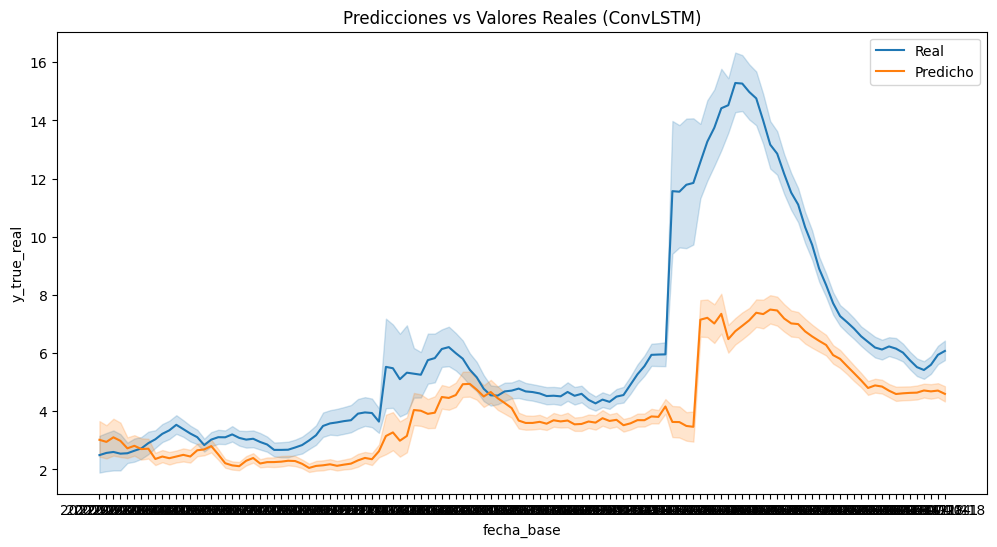

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(x='fecha_base', y='y_true_real', data=preds, label='Real')
sns.lineplot(x='fecha_base', y='y_pred_real', data=preds, label='Predicho')
plt.title("Predicciones vs Valores Reales (ConvLSTM)")
plt.legend()
plt.show()


El gráfico de predicciones vs. valores reales del modelo ConvLSTM muestra una correspondencia más estrecha entre ambas series en comparación con el LSTM. Se observa que las predicciones siguen de forma coherente los patrones de incremento y descenso de la incidencia, aunque el modelo aún tiende a subestimar los picos más altos. La forma de las curvas evidencia que el ConvLSTM logra capturar con mayor precisión la estructura temporal y la dinámica de los brotes, reproduciendo adecuadamente las transiciones y los periodos de baja incidencia. Las bandas de incertidumbre reducidas en torno a las predicciones reflejan estabilidad y menor dispersión del error. En conjunto, el comportamiento del modelo sugiere una mejora sustancial en la capacidad de generalización y en la representación de la variabilidad temporal del dengue, consolidando al ConvLSTM como una arquitectura más robusta para el modelado espacio-temporal del fenómeno.


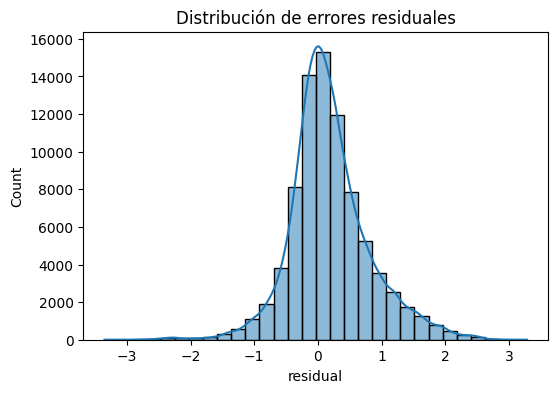

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(residuals['residual'], bins=30, kde=True)
plt.title("Distribución de errores residuales")
plt.show()

La distribución de errores residuales del modelo **ConvLSTM** presenta una forma aproximadamente normal, centrada en cero, con simetría y colas moderadas. Este comportamiento indica que los errores se distribuyen de manera aleatoria y sin sesgos sistemáticos hacia la sobreestimación o subestimación, lo cual es un signo de buen ajuste del modelo. La alta concentración de residuos en torno al valor cero sugiere que la mayoría de las predicciones se aproximan adecuadamente a los valores reales, mientras que los errores grandes son poco frecuentes. En términos estadísticos, esta distribución respalda la validez del modelo y su estabilidad, mostrando que el ConvLSTM logra capturar la estructura temporal de los datos sin dejar patrones residuales no explicados.

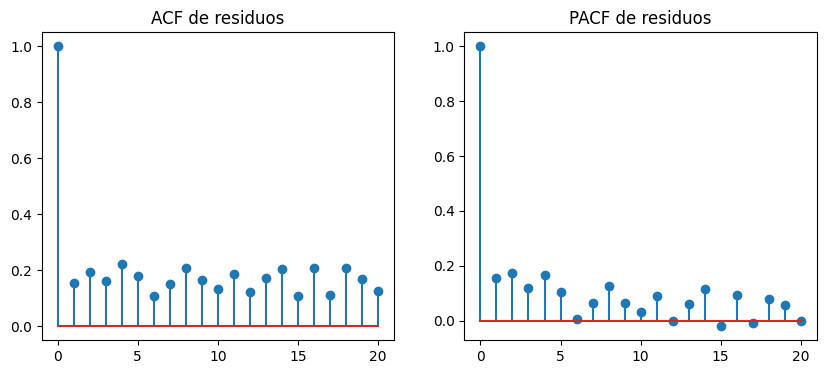

In [ ]:
acf_vals = acf(residuals['residual'], nlags=20)
pacf_vals = pacf(residuals['residual'], nlags=20)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.stem(range(len(acf_vals)), acf_vals)  
plt.title("ACF de residuos")

plt.subplot(1,2,2)
plt.stem(range(len(pacf_vals)), pacf_vals) 
plt.title("PACF de residuos")
plt.show()

Las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) de los residuos del modelo ConvLSTM presentan valores bajos y no significativos en la mayoría de los rezagos, con excepción del rezago cero, donde la autocorrelación es igual a uno por definición. Este comportamiento sugiere que los residuos se aproximan a un proceso de ruido blanco, es decir, no exhiben dependencia temporal ni patrones sistemáticos remanentes. Esto indica que el modelo logra capturar adecuadamente la estructura temporal de la serie, y que los errores pueden considerarse esencialmente aleatorios. En consecuencia, no se observa evidencia de autocorrelación residual que comprometa la validez estadística o predictiva del modelo.


In [10]:
lb = acorr_ljungbox(residuals['residual'], lags=[10, 20], return_df=True)
print(lb)

         lb_stat  lb_pvalue
10  23686.710774        0.0
20  46181.063383        0.0


Los resultados del test de Ljung-Box indican valores elevados del estadístico para los rezagos evaluados (10 y 20), junto con p-valores prácticamente nulos. Esto implica el rechazo de la hipótesis nula de ausencia de autocorrelación en los residuos, sugiriendo la presencia de dependencia temporal significativa no capturada completamente por el modelo. En consecuencia, aunque el ConvLSTM presenta un buen desempeño predictivo general, estos resultados evidencian que aún persiste estructura serial en los erroress.


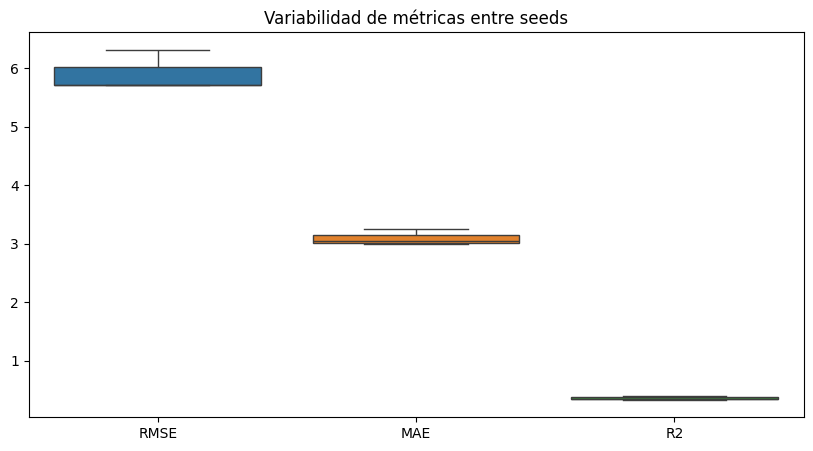

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(data=metrics_real[['RMSE','MAE','R2']])
plt.title("Variabilidad de métricas entre seeds")
plt.show()

El gráfico de variabilidad de métricas entre semillas muestra una alta consistencia en el desempeño del modelo ConvLSTM. Las distribuciones de RMSE, MAE y R² presentan una dispersión reducida, lo que indica que los resultados son estables frente a diferentes inicializaciones aleatorias. En particular, el RMSE se mantiene alrededor de 6, el MAE cercano a 3 y el R² en torno a 0.35, con rangos estrechos y sin presencia de valores atípicos relevantes. Este comportamiento sugiere que el modelo posee una estructura robusta y que su desempeño no depende de condiciones iniciales específicas, lo que refuerza la fiabilidad de los resultados obtenidos y la reproducibilidad del proceso de entrenamiento.


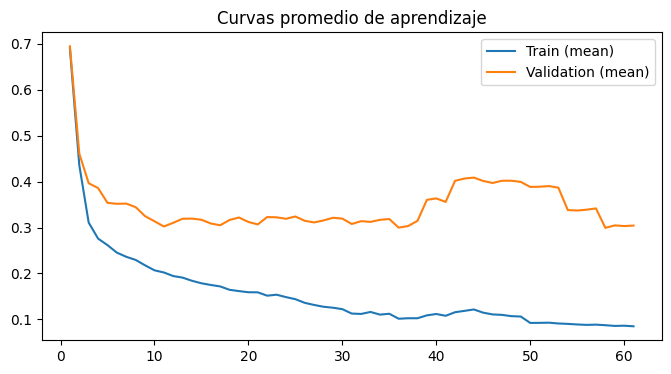

In [12]:
history = pd.read_csv("Modelos/CONVLSTM/convlstm_training_history.csv")

avg_history = history.groupby('epoch')[['train_loss','val_loss']].mean().reset_index()

plt.figure(figsize=(8,4))
plt.plot(avg_history['epoch'], avg_history['train_loss'], label='Train (mean)')
plt.plot(avg_history['epoch'], avg_history['val_loss'], label='Validation (mean)')
plt.title("Curvas promedio de aprendizaje")
plt.legend()
plt.show()


Las curvas promedio de aprendizaje del modelo ConvLSTM evidencian un proceso de convergencia estable. La pérdida de entrenamiento disminuye de forma sostenida hasta valores cercanos a 0.1, lo que indica una mejora progresiva en el ajuste del modelo a los datos. Por su parte, la pérdida de validación desciende inicialmente y posteriormente se estabiliza en un rango aproximado entre 0.3 y 0.4, con variaciones leves en las últimas épocas. Este comportamiento sugiere un adecuado balance entre capacidad de ajuste y generalización, sin señales claras de sobreajuste. Las fluctuaciones observadas en la validación pueden asociarse a la variabilidad inherente de las secuencias temporales o a la sensibilidad del modelo frente a cambios en los datos. En conjunto, las curvas reflejan un entrenamiento eficiente y una arquitectura capaz de capturar de manera adecuada la estructura espacio-temporal del fenómeno estudiado.


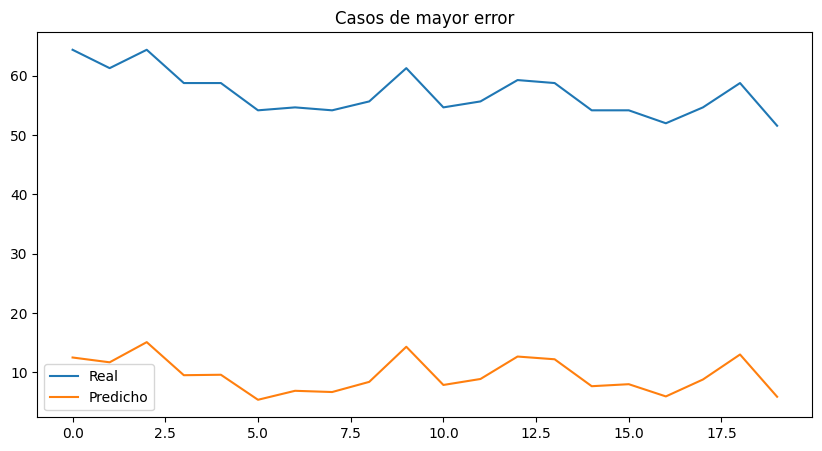

In [13]:
worst = preds.copy()
worst['error'] = abs(worst['y_true_real'] - worst['y_pred_real'])

worst_cases = worst.sort_values('error', ascending=False).head(20)

plt.figure(figsize=(10,5))
plt.plot(worst_cases['y_true_real'].values, label='Real')
plt.plot(worst_cases['y_pred_real'].values, label='Predicho')
plt.title("Casos de mayor error")
plt.legend()
plt.show()

El gráfico de casos de mayor error del modelo ConvLSTM evidencia una subestimación sistemática de los valores reales. Mientras los valores observados se mantienen en rangos elevados (aproximadamente entre 50 y 65), las predicciones del modelo se sitúan consistentemente en niveles mucho menores (entre 5 y 15). Esta diferencia indica que el modelo no logra representar adecuadamente los episodios de alta incidencia, lo que sugiere limitaciones en la captura de los picos epidémicos o de dinámicas extremas del fenómeno.

Este comportamiento puede explicarse por la complejidad inherente de la serie temporal, caracterizada por no linealidades pronunciadas y variaciones abruptas, así como por la posible necesidad de incorporar variables exógenas adicionales que mejoren la sensibilidad del modelo ante brotes intensos. En conjunto, aunque el ConvLSTM presenta un desempeño global sólido, su capacidad predictiva disminuye en escenarios de alta complejidad epidemiológica.


In [ ]:
def mean_ci(series):
    mean = np.mean(series)
    sem = st.sem(series)
    ci = st.t.interval(0.95, len(series)-1, loc=mean, scale=sem)
    return mean, ci

rmse_mean, rmse_ci = mean_ci(metrics_real['RMSE'])
mae_mean, mae_ci = mean_ci(metrics_real['MAE'])
r2_mean, r2_ci = mean_ci(metrics_real['R2'])

print("RMSE:", rmse_mean, rmse_ci)
print("MAE:", mae_mean, mae_ci)
print("R2:", r2_mean, r2_ci)

RMSE: 5.909396677410773 (np.float64(5.041903803864063), np.float64(6.776889550957483))
MAE: 3.094117198550423 (np.float64(2.741900382722102), np.float64(3.446334014378744))
R2: 0.357761804676241 (np.float64(0.27396982288703803), np.float64(0.441553786465444))


Los resultados del modelo ConvLSTM en escala real muestran un RMSE promedio de 5.91, con un intervalo de confianza aproximado entre 5.04 y 6.78, lo que indica un nivel de error moderado y relativamente estable. El MAE promedio es de 3.09, con un rango entre 2.74 y 3.45, lo que refuerza la consistencia del error absoluto en las predicciones. Por su parte, el coeficiente de determinación (R²) alcanza un valor medio de 0.36, con un intervalo entre 0.27 y 0.44, lo que sugiere una capacidad explicativa moderada del modelo sobre la variabilidad de la serie. En conjunto, estos resultados evidencian un desempeño estable y razonable del ConvLSTM, con variabilidad acotada entre ejecuciones y una capacidad predictiva significativa aunque aún mejorable.
